Cell 0 — Download the database (SKIP: already downloaded)

In [1]:
# Run ONCE to download the database into your project folder, then never again.
# If you already have lichess_db_puzzle.csv.zst in the folder, skip this.
import urllib.request, os
PROJECT = "D:/Documents/dissertation"
dbpath = f"{PROJECT}/lichess_db_puzzle.csv.zst"
if not os.path.exists(dbpath):
    print("Downloading (large file, be patient)...")
    urllib.request.urlretrieve("https://database.lichess.org/lichess_db_puzzle.csv.zst", dbpath)
    print("Downloaded.")
else:
    print("Database already present, skipping download.")

Downloaded.


Cell 1 — Build the working set and train/test split (SKIP: already built)

In [2]:
import pandas as pd, os
PROJECT = "D:/Documents/dissertation"

df = pd.read_csv(f"{PROJECT}/lichess_db_puzzle.csv.zst")
df["n_moves"] = df["Moves"].str.split().apply(len)
print("Full database:", df.shape)

# main working set: rating 1000-1500, multi-step
working = df[(df.Rating >= 1000) & (df.Rating <= 1500) & (df.n_moves >= 4)] \
            .sample(10000, random_state=42).reset_index(drop=True)

# fixed 80/20 train/test split
test_set  = working.sample(frac=0.2, random_state=42)
train_set = working.drop(test_set.index).reset_index(drop=True)
test_set  = test_set.reset_index(drop=True)

train_set.to_csv(f"{PROJECT}/train_set.csv", index=False)
test_set.to_csv(f"{PROJECT}/test_set.csv", index=False)
print(f"Train: {len(train_set)} | Test: {len(test_set)}")
print("Overlap (should be 0):", len(set(train_set.PuzzleId) & set(test_set.PuzzleId)))

Full database: (6100960, 12)
Train: 8000 | Test: 2000
Overlap (should be 0): 0


Cell 2 — Imports and load data (RUN: needed every session)

In [1]:
# ===== CELL 2 | RUN - loads libraries and data into memory =====
import pandas as pd, numpy as np, chess, os, json, glob
import gymnasium as gym
from gymnasium import spaces
import torch, torch.nn as nn
from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

PROJECT = "D:/Documents/dissertation"
train_set = pd.read_csv(f"{PROJECT}/train_set.csv")
test_set  = pd.read_csv(f"{PROJECT}/test_set.csv")
print("GPU:", torch.cuda.is_available(), "| Train:", len(train_set), "| Test:", len(test_set))

GPU: True | Train: 8000 | Test: 2000


Cell 2a — Dataset overview: size, rating spread, puzzle length

In [2]:
# ===== 2a | DATASET OVERVIEW (for the writeup) =====
import pandas as pd
PROJECT = "D:/Documents/dissertation"
df = pd.read_csv(f"{PROJECT}/lichess_db_puzzle.csv.zst")
df["n_moves"] = df["Moves"].str.split().apply(len)

print("Total puzzles in database:", f"{len(df):,}")
print("\nRating distribution:")
print(df["Rating"].describe()[["min", "25%", "50%", "75%", "max"]].round(0))
print("\nPuzzle length (number of moves), most common:")
print(df["n_moves"].value_counts().sort_index().head(10))

Total puzzles in database: 6,100,960

Rating distribution:
min     399.0
25%    1042.0
50%    1415.0
75%    1874.0
max    3322.0
Name: Rating, dtype: float64

Puzzle length (number of moves), most common:
n_moves
2      905415
4     3091726
6     1601048
8      358050
10      96823
12      30678
14      10754
16       4040
18       1449
20        616
Name: count, dtype: int64


Cell 2b — A single puzzle: its FEN string and the board it describes

Rating: 1939 | Themes: crushing hangingPiece long middlegame
FEN (the raw text describing the position):
  r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2R1/PqP2bPP/7K b - - 0 24


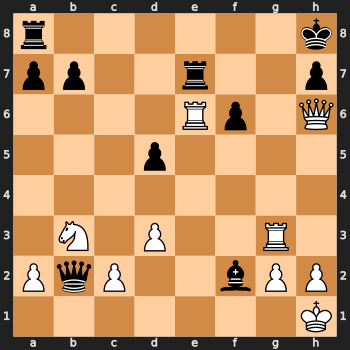

In [3]:
# ===== 2b | ONE PUZZLE: FEN STRING AND RENDERED BOARD (for the writeup) =====
import chess, chess.svg
from IPython.display import display, SVG

row = df.iloc[0]
print("Rating:", row["Rating"], "| Themes:", row["Themes"])
print("FEN (the raw text describing the position):")
print(" ", row["FEN"])

board = chess.Board(row["FEN"])
display(SVG(chess.svg.board(board, size=350)))

Cell 2c — The setup move and the position the agent solves from

The opponent's setup move is played first: f2g3
The agent must then find: ['e6e7', 'b2b1', 'b3c1', 'b1c1', 'h6c1']
Side to move (the agent): White


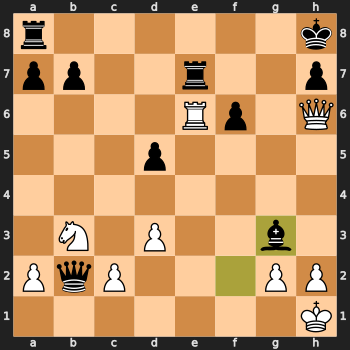

In [4]:
# ===== 2c | THE SETUP MOVE, THEN THE AGENT'S TURN (for the writeup) =====
moves = row["Moves"].split()
board = chess.Board(row["FEN"])
board.push_uci(moves[0])          # opponent's setup move plays automatically

print("The opponent's setup move is played first:", moves[0])
print("The agent must then find:", moves[1:])
print("Side to move (the agent):", "White" if board.turn else "Black")
display(SVG(chess.svg.board(board, lastmove=chess.Move.from_uci(moves[0]), size=350)))

Cell 2d — Checking whether a puzzle is solved

In [5]:
# ===== 2d | THE "SOLVED?" CHECK (for the writeup) =====
def is_puzzle_solved(fen, correct_moves, attempted_moves):
    """
    fen:             the puzzle's starting position (a FEN string)
    correct_moves:   the full official move list from the database
    attempted_moves: the moves the agent actually played
    Returns True if the attempt matches the correct solution.
    """
    board = chess.Board(fen)
    board.push_uci(correct_moves[0])   # play the opponent's setup move
    solution = correct_moves[1:]       # the moves the agent must reproduce
    return attempted_moves == solution

row = df.iloc[0]
moves = row["Moves"].split()
solution = moves[1:]
print("Correct attempt:", is_puzzle_solved(row["FEN"], moves, solution))

wrong = solution.copy()
wrong[0] = "a1a1"                       # deliberately break the first move
print("Wrong attempt:  ", is_puzzle_solved(row["FEN"], moves, wrong))

Correct attempt: True
Wrong attempt:   False


Cell 3 — Environment: move encoding, board potential, and puzzle environment (RUN: defines the environment)

In [3]:
def move_to_index(move):
    return move.from_square * 64 + move.to_square

def board_potential(board, my_color):
    values = {chess.PAWN:1, chess.KNIGHT:3, chess.BISHOP:3,
              chess.ROOK:5, chess.QUEEN:9, chess.KING:0}
    score = 0
    for pt, val in values.items():
        score += val * len(board.pieces(pt, my_color))
        score -= val * len(board.pieces(pt, not my_color))
    if board.is_checkmate(): score += 20
    elif board.is_check():   score += 0.5
    return score

class ChessPuzzleEnv(gym.Env):
    def __init__(self, puzzles, reward_mode="sparse"):
        super().__init__()
        self.puzzles = puzzles.reset_index(drop=True)
        self.reward_mode = reward_mode
        self.observation_space = spaces.Box(low=0, high=1, shape=(13, 8, 8), dtype=np.float32)
        self.action_space = spaces.Discrete(4096)

    def _encode_board(self):
        pts = [chess.PAWN, chess.KNIGHT, chess.BISHOP, chess.ROOK, chess.QUEEN, chess.KING]
        planes = np.zeros((13, 8, 8), dtype=np.float32)
        for i, pt in enumerate(pts):
            for sq in self.board.pieces(pt, chess.WHITE):
                planes[i, sq // 8, sq % 8] = 1.0
            for sq in self.board.pieces(pt, chess.BLACK):
                planes[i + 6, sq // 8, sq % 8] = 1.0
        if self.board.turn == chess.WHITE:
            planes[12, :, :] = 1.0
        return planes

    def action_masks(self):
        mask = np.zeros(4096, dtype=bool)
        for mv in self.board.legal_moves:
            mask[move_to_index(mv)] = True
        return mask

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.puzzle = self.puzzles.sample(1).iloc[0]
        self.board = chess.Board(self.puzzle["FEN"])
        self.moves = self.puzzle["Moves"].split()
        self.board.push_uci(self.moves[0])
        self.solution = self.moves[1:]
        self.step_idx = 0
        self.my_color = self.board.turn
        self.prev_potential = board_potential(self.board, self.my_color)
        return self._encode_board(), {}

    def step(self, action):
        terminated = False
        reward = 0.0
        chosen = None
        for mv in self.board.legal_moves:
            if move_to_index(mv) == action:
                chosen = mv; break
        if chosen is None:
            return self._encode_board(), 0.0, True, False, {}
        expected = chess.Move.from_uci(self.solution[self.step_idx])
        if chosen == expected:
            self.board.push(chosen)
            self.step_idx += 1
            if self.reward_mode == "progress":
                reward = 0.1
            elif self.reward_mode == "potential":
                new_p = board_potential(self.board, self.my_color)
                reward = new_p - self.prev_potential
                self.prev_potential = new_p
            if self.step_idx >= len(self.solution):
                reward = 1.0
                terminated = True
        else:
            terminated = True
            if self.reward_mode == "penalty":
                reward = -0.1
        return self._encode_board(), reward, terminated, False, {}

print("Environment defined.")

Environment defined.


Cell 4 — CNN network and evaluation helper (RUN: defines the network)

In [4]:
class ChessCNN(BaseFeaturesExtractor):
    def __init__(self, observation_space, features_dim=256):
        super().__init__(observation_space, features_dim)
        n_planes = observation_space.shape[0]
        self.cnn = nn.Sequential(
            nn.Conv2d(n_planes, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),       nn.ReLU(),
            nn.Flatten(),
        )
        with torch.no_grad():
            n_flat = self.cnn(torch.zeros(1, *observation_space.shape)).shape[1]
        self.linear = nn.Sequential(nn.Linear(n_flat, features_dim), nn.ReLU())
    def forward(self, x):
        return self.linear(self.cnn(x))

def mask_fn(env):
    return env.action_masks()

def evaluate_partial(model, puzzles, n=300):
    env = ActionMasker(ChessPuzzleEnv(puzzles, reward_mode="sparse"), mask_fn)
    total_progress = 0.0; full = 0
    for _ in range(n):
        obs, info = env.reset(); base = env.unwrapped
        sol_len = len(base.solution); done = False
        while not done:
            m = env.action_masks()
            a, _ = model.predict(obs, action_masks=m, deterministic=True)
            obs, r, term, trunc, info = env.step(int(a)); done = term or trunc
        total_progress += base.step_idx / sol_len
        if base.step_idx == sol_len: full += 1
    return total_progress / n * 100, full / n * 100

print("CNN and helpers defined.")

CNN and helpers defined.


Cell 5 — Training loop (SKIP: results already exist; only defines RESULTS_DIR)

In [5]:
# ===== CELL 5 | SKIP the training - results already exist =====
# This defines RESULTS_DIR (needed below). The loop is left here for record;
# if you run it, it will just print [skip] for all 20 completed runs - it will NOT retrain.
RESULTS_DIR = f"{PROJECT}/experiment_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

STRATEGIES = ["sparse", "progress", "potential", "penalty"]
SEEDS = [42, 43, 44, 45, 46]
STEPS = 600000
policy_kwargs = dict(features_extractor_class=ChessCNN,
                     features_extractor_kwargs=dict(features_dim=256))

# --- training loop (already complete - do not need to run) ---
# def run_one(mode, seed):
#     ... (kept commented so it can't accidentally retrain) ...
print("RESULTS_DIR defined. Training already complete - skip the loop.")

RESULTS_DIR defined. Training already complete - skip the loop.


Cell 6 — Results summary table (RUN)

In [6]:
# ===== CELL 6 | RUN - main results table =====
STRATEGIES = ["sparse", "progress", "potential", "penalty"]
main = {m: {"full": [], "progress": []} for m in STRATEGIES}
for path in glob.glob(f"{RESULTS_DIR}/*.json"):
    if "difficulty" in path: continue
    r = json.load(open(path))
    if r["mode"] in main:
        main[r["mode"]]["full"].append(r["full"])
        main[r["mode"]]["progress"].append(r["progress"])

print(f"{'strategy':>10} | {'full solve %':>16} | {'avg progress %':>16} | seeds")
print("-" * 62)
for m in STRATEGIES:
    f = np.array(main[m]["full"]); p = np.array(main[m]["progress"])
    print(f"{m:>10} | {f.mean():6.1f} ± {f.std():4.1f}    | {p.mean():6.1f} ± {p.std():4.1f}    | {len(f)}")

  strategy |     full solve % |   avg progress % | seeds
--------------------------------------------------------------
    sparse |    0.1 ±  0.2    |    2.6 ±  0.5    | 5
  progress |    4.3 ±  1.3    |   12.6 ±  1.7    | 5
 potential |    0.7 ±  0.5    |    6.9 ±  1.2    | 5
   penalty |    0.5 ±  0.7    |    3.7 ±  1.5    | 5


Cell 7 — Statistical tests: ANOVA and Tukey HSD (RUN)

In [7]:
# ===== CELL 7 | RUN - statistical tests =====
from scipy import stats
import statsmodels.stats.multicomp as mc

def analyse(metric):
    print(f"\n{'='*55}\n  METRIC: {metric}\n{'='*55}")
    groups = [main[m][metric] for m in STRATEGIES]
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"  ANOVA:  F = {f_stat:.2f},  p = {p_val:.4f}")
    print("  -> Significant (p<0.05)" if p_val < 0.05 else "  -> Not significant")
    values, labels = [], []
    for m in STRATEGIES:
        values += main[m][metric]; labels += [m]*len(main[m][metric])
    print(mc.pairwise_tukeyhsd(np.array(values), np.array(labels), alpha=0.05))

analyse("full")
analyse("progress")


  METRIC: full
  ANOVA:  F = 26.29,  p = 0.0000
  -> Significant (p<0.05)
   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
  penalty potential   0.2667 0.9595 -1.2799  1.8133  False
  penalty  progress   3.8667    0.0  2.3201  5.4133   True
  penalty    sparse  -0.3333 0.9253 -1.8799  1.2133  False
potential  progress      3.6    0.0  2.0534  5.1466   True
potential    sparse     -0.6 0.6888 -2.1466  0.9466  False
 progress    sparse     -4.2    0.0 -5.7466 -2.6534   True
----------------------------------------------------------

  METRIC: progress
  ANOVA:  F = 48.40,  p = 0.0000
  -> Significant (p<0.05)
    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower    upper  reject
-----------------------------------------------------------
  penalty potential   3.2434 0.0126   0.6335  5.8533   True
  penalty  progr

Cell 8 — Comparison bar chart (RUN)

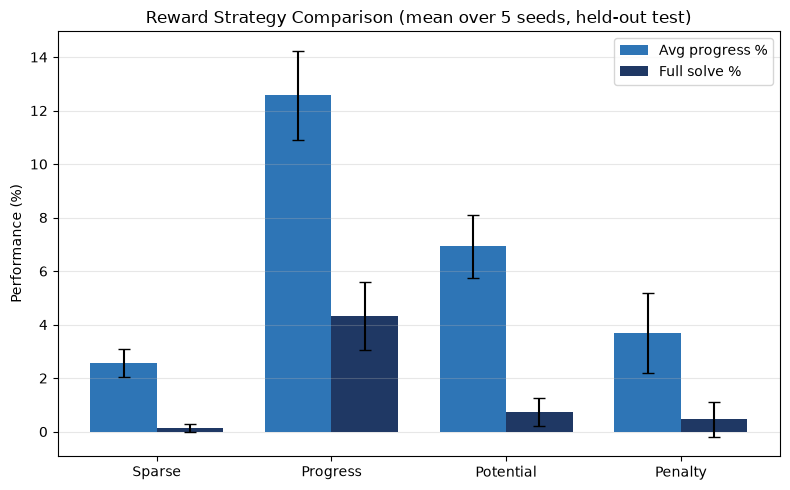

In [8]:
# ===== CELL 8 | RUN - saves chart_comparison.png =====
import matplotlib.pyplot as plt
x = np.arange(len(STRATEGIES)); w = 0.38
prog_m = [np.mean(main[m]["progress"]) for m in STRATEGIES]
prog_s = [np.std(main[m]["progress"]) for m in STRATEGIES]
full_m = [np.mean(main[m]["full"]) for m in STRATEGIES]
full_s = [np.std(main[m]["full"]) for m in STRATEGIES]

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x-w/2, prog_m, w, yerr=prog_s, capsize=4, label="Avg progress %", color="#2E75B6")
ax.bar(x+w/2, full_m, w, yerr=full_s, capsize=4, label="Full solve %", color="#1F3864")
ax.set_xticks(x); ax.set_xticklabels([s.capitalize() for s in STRATEGIES])
ax.set_ylabel("Performance (%)")
ax.set_title("Reward Strategy Comparison (mean over 5 seeds, held-out test)")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PROJECT}/chart_comparison.png", dpi=150)
plt.show()

Cell 9 — Difficulty line chart (RUN)

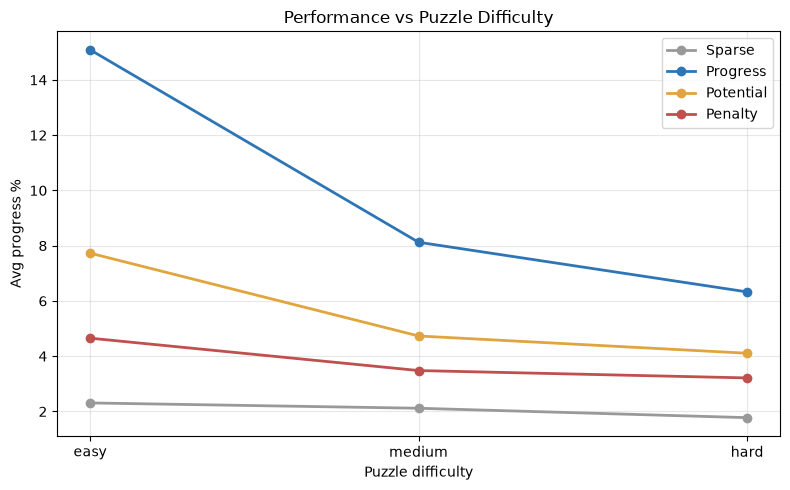

In [9]:
# ===== CELL 9 | RUN - saves chart_difficulty.png =====
diff = json.load(open(f"{PROJECT}/difficulty_results.json"))
BANDS = ["easy", "medium", "hard"]
COLORS = ["#999999", "#2E75B6", "#E0A53E", "#C0504D"]
agg = {m: {b: [] for b in BANDS} for m in STRATEGIES}
for r in diff.values():
    agg[r["mode"]][r["band"]].append(r["progress"])

fig, ax = plt.subplots(figsize=(8,5))
for m, c in zip(STRATEGIES, COLORS):
    means = [np.mean(agg[m][b]) for b in BANDS]
    ax.plot(BANDS, means, marker="o", linewidth=2, label=m.capitalize(), color=c)
ax.set_ylabel("Avg progress %"); ax.set_xlabel("Puzzle difficulty")
ax.set_title("Performance vs Puzzle Difficulty")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PROJECT}/chart_difficulty.png", dpi=150)
plt.show()

Cell 10 — Render an example puzzle board (RUN)

Puzzle rating: 1292
Solution to find: ['d7d1', 'b1h7', 'g8h8', 'g1d1', 'd8g5']


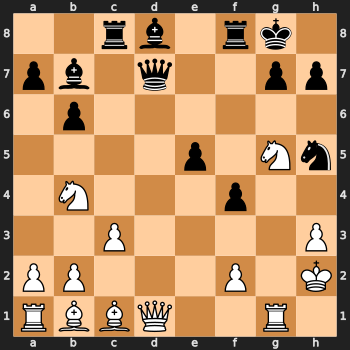

In [10]:
# ===== CELL 10 | RUN - renders an example puzzle board =====
import chess.svg
from IPython.display import SVG, display

row = test_set.iloc[0]
board = chess.Board(row["FEN"])
board.push_uci(row["Moves"].split()[0])
print("Puzzle rating:", row["Rating"])
print("Solution to find:", row["Moves"].split()[1:])
display(SVG(chess.svg.board(board, size=350)))